In [1]:
import polars as pl

pdb_af3 = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet"
).filter(pl.col("pdb") != "8trr")

In [2]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu


def plot_rmsd_bars_all_by_species(
    pdb_df: pl.DataFrame, inf_type: str, title: str | None = None
) -> plt.Figure:
    labels = ["Peptide RMSD", "MHC RMSD", "TCR RMSD"]
    cols = [
        f"peptide_rmsd_{inf_type}_4",
        f"mhc_rmsd_{inf_type}_4",
        f"tcr_rmsd_{inf_type}_4",
    ]

    # Normalize species labels and keep only human/mouse
    df = pdb_df.with_columns(
        pl.col("mhc_2_species").cast(pl.Utf8).str.to_lowercase()
    ).filter(pl.col("mhc_2_species").is_in(["human", "mouse"]))

    species_present = df.select(pl.col("mhc_2_species").unique()).to_series().to_list()
    if not species_present:
        # Fall back to your original single-panel plot if no species present
        # (kept simple rather than raising)
        replic_means = df.filter(pl.col("replication")).select(cols).to_numpy()
        post_means = df.filter(~pl.col("replication")).select(cols).to_numpy()

        x = np.arange(len(labels))
        width = 0.35
        fig, ax = plt.subplots(figsize=(8, 5))
        if replic_means.size:
            ax.boxplot(
                replic_means,
                positions=x - width / 2,
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor="tab:blue", edgecolor="black"),
                whiskerprops=dict(color="tab:blue"),
                capprops=dict(color="tab:blue"),
                medianprops=dict(color="black"),
                flierprops=dict(markeredgecolor="tab:blue"),
            )
        if post_means.size:
            ax.boxplot(
                post_means,
                positions=x + width / 2,
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor="tab:orange", edgecolor="black"),
                whiskerprops=dict(color="tab:orange"),
                capprops=dict(color="tab:orange"),
                medianprops=dict(color="black"),
                flierprops=dict(markeredgecolor="tab:orange"),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("RMSD between true and crystal structure (Å)")
        if title:
            ax.set_title(title)

        pre_patch = Patch(
            facecolor="tab:blue",
            edgecolor="black",
            label=f"Pre-training (n={replic_means.shape[0]})",
        )
        post_patch = Patch(
            facecolor="tab:orange",
            edgecolor="black",
            label=f"Post-training (n={post_means.shape[0]})",
        )
        ax.legend(handles=[pre_patch, post_patch], loc="upper left")
        plt.tight_layout()
        return fig

    # Multi-panel by species
    n_panels = len(species_present)
    fig, axes = plt.subplots(
        1, n_panels, figsize=(8 * n_panels, 5), sharey=True, squeeze=False
    )
    axes = axes[0]

    x = np.arange(len(labels))
    width = 0.35

    for i, species in enumerate(species_present):
        ax = axes[i]
        sub = df.filter(pl.col("mhc_2_species") == species)

        replic_means = sub.filter(pl.col("replication")).select(cols).to_numpy()
        post_means = sub.filter(~pl.col("replication")).select(cols).to_numpy()

        if replic_means.size:
            ax.boxplot(
                replic_means,
                positions=x - width / 2,
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor="tab:blue", edgecolor="black"),
                whiskerprops=dict(color="tab:blue"),
                capprops=dict(color="tab:blue"),
                medianprops=dict(color="black"),
                flierprops=dict(markeredgecolor="tab:blue"),
            )
        if post_means.size:
            ax.boxplot(
                post_means,
                positions=x + width / 2,
                widths=width,
                patch_artist=True,
                boxprops=dict(facecolor="tab:orange", edgecolor="black"),
                whiskerprops=dict(color="tab:orange"),
                capprops=dict(color="tab:orange"),
                medianprops=dict(color="black"),
                flierprops=dict(markeredgecolor="tab:orange"),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("RMSD between true and crystal structure (Å)")
        ax.set_title(
            f"{species.capitalize()}  "
            f"(pre n={replic_means.shape[0]}, post n={post_means.shape[0]})"
        )

        if i == 0:
            pre_patch = Patch(
                facecolor="tab:blue", edgecolor="black", label="Pre-training"
            )
            post_patch = Patch(
                facecolor="tab:orange", edgecolor="black", label="Post-training"
            )
            ax.legend(handles=[pre_patch, post_patch], loc="upper left")

    if title:
        fig.suptitle(title, y=1.02)

    plt.tight_layout()
    return fig


def plot_cdr_rmsd_by_species_with_points(
    pdb_df: pl.DataFrame,
    title: str | None = None,
    species_col: str = "mhc_1_species",
    class_col: str = "mhc_class",
    rmsd_col: str = "cdr_rmsd_af3_4",
    jitter: float = 0.08,
    point_alpha: float = 0.7,
    point_size: float = 24.0,
) -> plt.Figure:
    """
    Two boxes: left=Human, right=Mouse. Each point is a sample's CDR RMSD,
    overlaid and colored by MHC class (I=blue, II=orange). Also performs a
    Kruskal–Wallis test comparing Human vs Mouse distributions.

    Assumes:
      - species_col contains 'human' or 'mouse' (case-insensitive; others ignored)
      - class_col contains 'I' or 'II'
      - rmsd_col is numeric and may have nulls
    """

    # Normalize species labels; keep only human/mouse; drop null RMSD
    df = (
        pdb_df.with_columns(pl.col(species_col).cast(pl.Utf8).str.to_lowercase())
        .filter(pl.col(species_col).is_in(["human", "mouse"]))
        .filter(pl.col(rmsd_col).is_not_null())
    )

    # Early exit if nothing to plot
    if df.height == 0:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(
            0.5,
            0.5,
            "No human/mouse data with non-null CDR RMSD.",
            ha="center",
            va="center",
        )
        ax.axis("off")
        return fig

    # Split values and classes
    human = df.filter(pl.col(species_col) == "human")
    mouse = df.filter(pl.col(species_col) == "mouse")

    human_vals = human.get_column(rmsd_col).to_numpy()
    mouse_vals = mouse.get_column(rmsd_col).to_numpy()

    # Prepare plot
    fig, ax = plt.subplots()
    positions = [0, 1]
    width = 0.4

    # Boxplots (unfilled so point colors are visible; whiskers/median in black)
    bp_human = ax.boxplot(
        [human_vals],
        positions=[positions[0]],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="white", edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="black"),
        showfliers=False,
    )
    bp_mouse = ax.boxplot(
        [mouse_vals],
        positions=[positions[1]],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="white", edgecolor="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="black"),
        showfliers=False,
    )

    # Overlay points, colored by MHC class (I=blue, II=orange), with jitter
    rng = np.random.default_rng()
    class_to_color = {"I": "tab:blue", "II": "tab:orange"}

    def scatter_points(subdf: pl.DataFrame, xpos: float):
        if subdf.height == 0:
            return 0, 0
        # Extract arrays
        vals = subdf.get_column(rmsd_col).to_numpy()
        clss = subdf.get_column(class_col).cast(pl.Utf8).to_list()
        # Jitter
        xs = xpos + rng.uniform(-jitter, jitter, size=len(vals))
        # Map colors
        colors = [class_to_color.get(c, "gray") for c in clss]
        ax.scatter(
            xs,
            vals,
            s=point_size,
            alpha=point_alpha,
            edgecolors="none",
            c=colors,
            zorder=2,
        )
        n_I = sum(1 for c in clss if c == "I")
        n_II = sum(1 for c in clss if c == "II")
        return n_I, n_II

    nI_h, nII_h = scatter_points(human, positions[0])
    nI_m, nII_m = scatter_points(mouse, positions[1])

    # Axes labels, ticks, title
    ax.tick_params(axis="y", labelsize=16)
    ax.tick_params(axis="x", labelsize=16)
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [
            f"Human (n={len(human_vals)})",
            f"Mouse (n={len(mouse_vals)})",
        ],
        fontsize=18,
    )
    ax.set_ylabel("CDR RMSD (Å)", fontsize=18)
    if title:
        ax.set_title(title, fontsize=18)

    # Legend (MHC class colors)
    legend_handles = [
        Patch(facecolor="tab:blue", edgecolor="black", label=f"MHC I"),
        Patch(facecolor="tab:orange", edgecolor="black", label=f"MHC II"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=16)

    # Kruskal–Wallis test (only if both groups non-empty)
    if len(human_vals) > 0 and len(mouse_vals) > 0:
        U, p = mannwhitneyu(human_vals, mouse_vals)
        p = f"p={p:.1e}" if p <= 0.05 else f"p={p:.2f}"
        # Print to console and annotate on figure
        # print(
        #     f"Kruskal–Wallis Human vs Mouse: H={H:.3f}, p={p:.3g}, n_human={len(human_vals)}, n_mouse={len(mouse_vals)}"
        # )
        ax.text(
            0.72,
            0.74,
            f"Mann-Whitney U, {p}",
            transform=ax.transAxes,
            ha="center",
            va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
            fontsize=16,
        )
    else:
        print("Kruskal–Wallis skipped (one or both groups empty).")

    plt.tight_layout()
    return fig

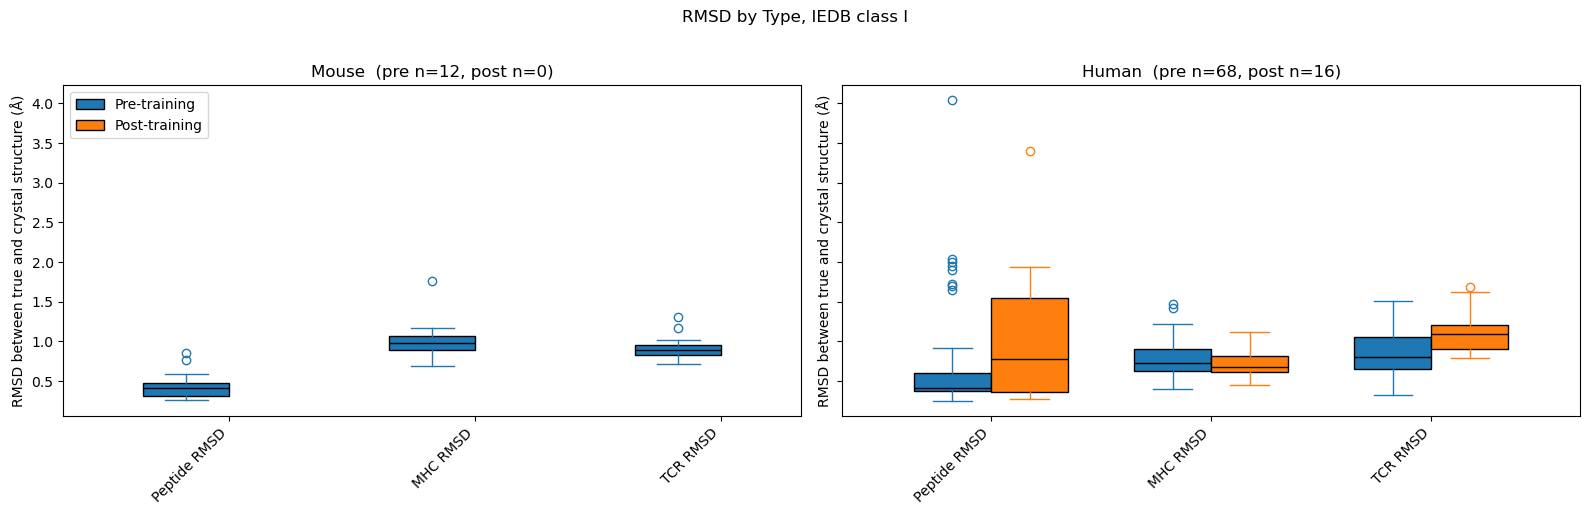

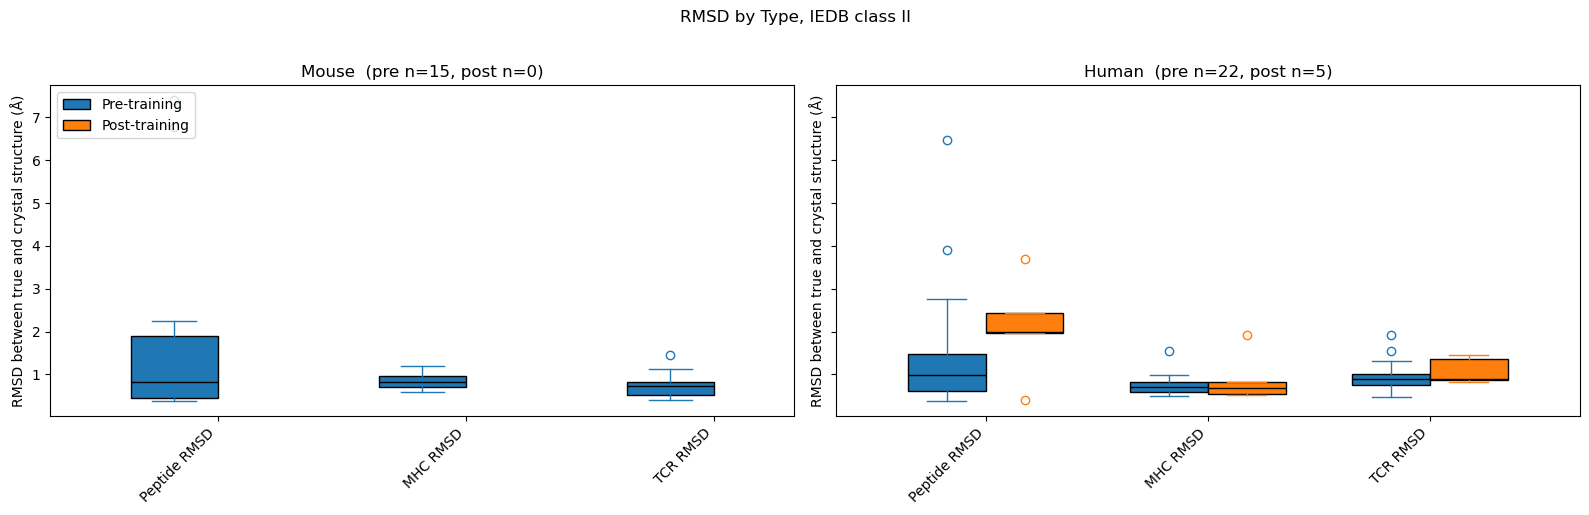

In [3]:
fig = plot_rmsd_bars_all_by_species(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    "af3",
    title="RMSD by Type, IEDB class I",
)
fig = plot_rmsd_bars_all_by_species(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    "af3",
    title="RMSD by Type, IEDB class II",
)

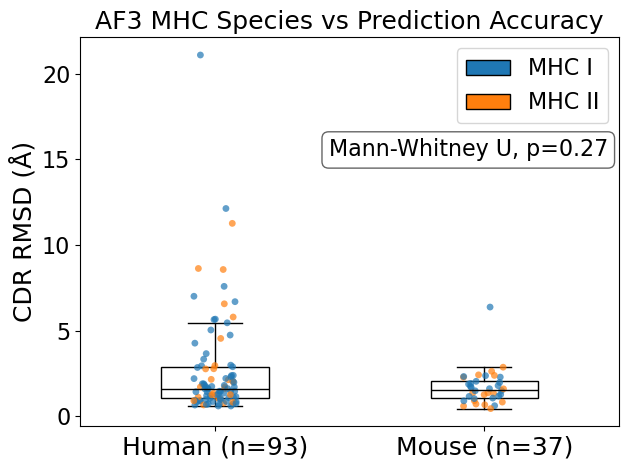

In [4]:
_ = plot_cdr_rmsd_by_species_with_points(
    pdb_af3.filter(pl.col("replication")),
    title="AF3 MHC Species vs Prediction Accuracy",
)

In [5]:
pdb_af3.filter(pl.col("mhc_class") == "II").select("cdr_rmsd_af3_4").min()

cdr_rmsd_af3_4
f64
0.450002


In [6]:
pdb_af3.filter(~pl.col("replication")).select("mhc_1_species").unique()

mhc_1_species
str
"""human"""
